In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Carica il dataset rischio alluvioni
flood = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\overstroming_geojson_lnglat.json")
print(f"Elementi caricati: {len(flood)}")
print(flood.columns.tolist())
flood.head()

Elementi caricati: 183
['Kans_code', 'Kans', 'Diepte_code', 'Diepte', 'geometry']


,Kans_code,Kans,Diepte_code,Diepte,geometry
0,2,Extreem kleine kans: <1/30.000 per jaar,1,,"MULTIPOLYGON (((4.89381 52.37255, 4.89382 52.3..."
1,3,Zeer kleine kans: 1/3.000 tot 1/30.000 per jaar,2,0 tot 50 cm,"MULTIPOLYGON (((4.89238 52.36984, 4.89239 52.3..."
2,2,Extreem kleine kans: <1/30.000 per jaar,1,,"MULTIPOLYGON (((4.88863 52.37163, 4.88798 52.3..."
3,3,Zeer kleine kans: 1/3.000 tot 1/30.000 per jaar,2,0 tot 50 cm,"MULTIPOLYGON (((4.88801 52.36623, 4.88948 52.3..."
4,2,Extreem kleine kans: <1/30.000 per jaar,1,,"MULTIPOLYGON (((4.90555 52.37349, 4.90554 52.3..."


In [2]:
print("Categorie di probabilità:")
print(flood['Kans'].value_counts())
print("\nCategorie di profondità:")
print(flood['Diepte'].value_counts())

Categorie di probabilità:
Kans
Geen significante overstromingskans                87
Zeer kleine kans: 1/3.000 tot 1/30.000 per jaar    52
Extreem kleine kans: <1/30.000 per jaar            31
Kleine kans: 1/300 tot 1/3.000 per jaar            13
Name: count, dtype: int64

Categorie di profondità:
Diepte
                   121
0 tot 50 cm         39
50 tot 200 cm       16
Meer dan 200 cm      7
Name: count, dtype: int64


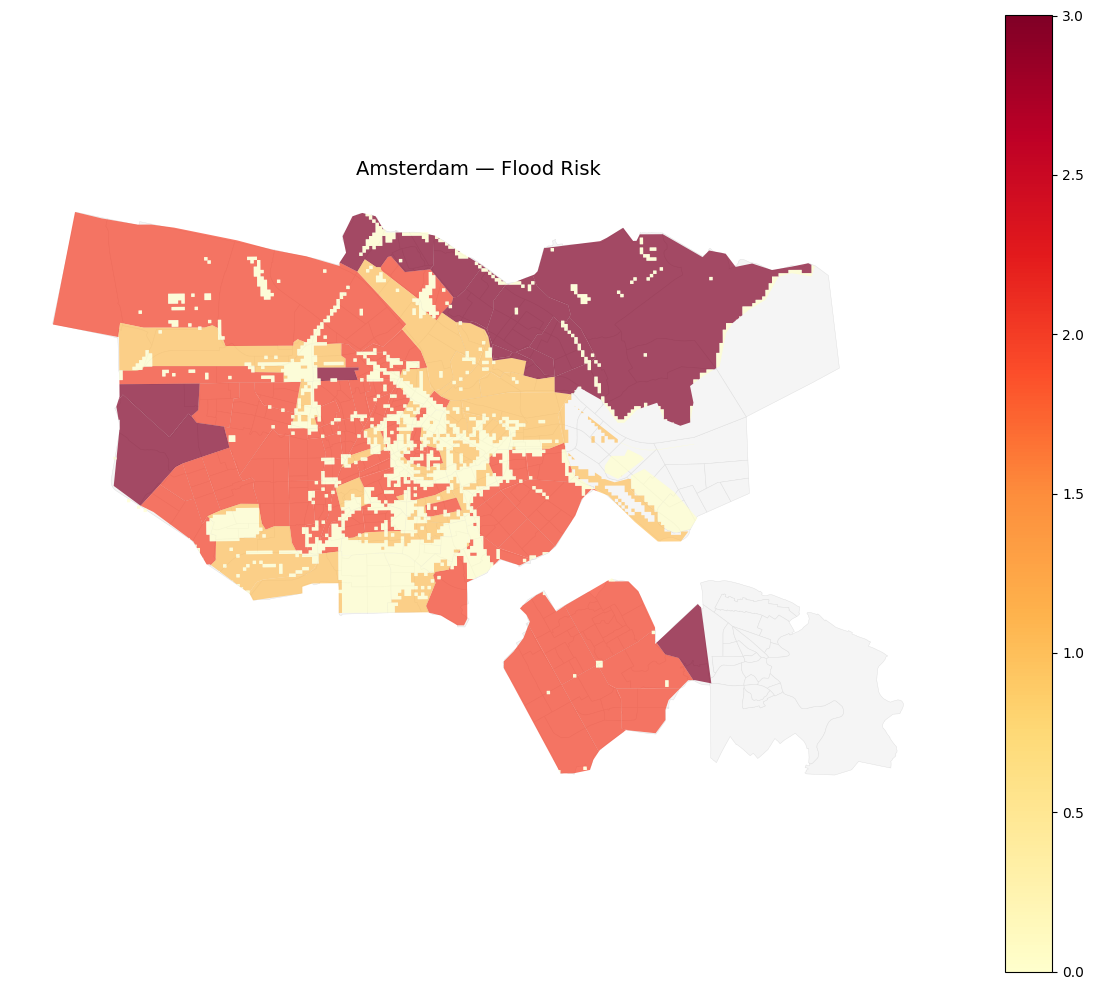

In [3]:
# Ordine del rischio dal più basso al più alto
ordine_rischio = [
    'Geen significante overstromingskans',
    'Extreem kleine kans: <1/30.000 per jaar',
    'Zeer kleine kans: 1/3.000 tot 1/30.000 per jaar',
    'Kleine kans: 1/300 tot 1/3.000 per jaar'
]

# Assegniamo un valore numerico al rischio
flood['rischio'] = flood['Kans'].map({
    'Geen significante overstromingskans': 0,
    'Extreem kleine kans: <1/30.000 per jaar': 1,
    'Zeer kleine kans: 1/3.000 tot 1/30.000 per jaar': 2,
    'Kleine kans: 1/300 tot 1/3.000 per jaar': 3
})

# Carichiamo i buurten come sfondo
buurten = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\geojson_lnglat_2.json")
flood_proj = flood.to_crs(buurten.crs)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Sfondo quartieri
buurten.plot(ax=ax, color='#f5f5f5', edgecolor='#dddddd', linewidth=0.3)

# Rischio alluvioni colorato
flood_proj.plot(
    column='rischio',
    cmap='YlOrRd',
    ax=ax,
    legend=True,
    alpha=0.7
)

ax.set_title('Amsterdam — Flood Risk', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('amsterdam_flood_risk.png', dpi=150, bbox_inches='tight')
plt.show()

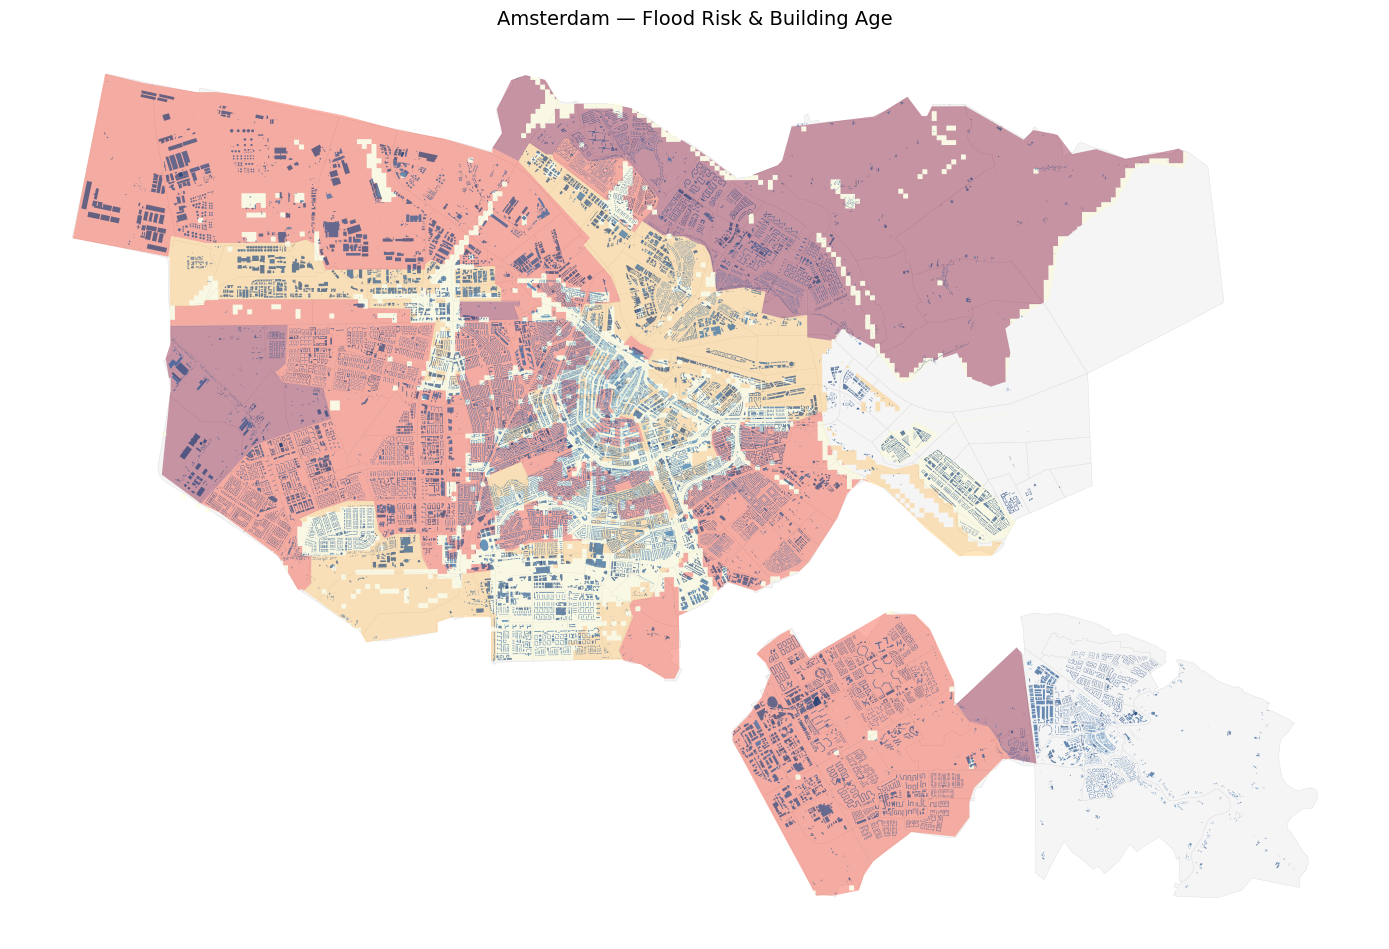

In [4]:
gdf = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\geojson_lnglat.json",
                    on_invalid="ignore")

gdf = gdf.to_crs(buurten.crs)
flood_proj = flood.to_crs(buurten.crs)

fig, ax = plt.subplots(1, 1, figsize=(14, 11))

# Sfondo quartieri
buurten.plot(ax=ax, color='#f5f5f5', edgecolor='#dddddd', linewidth=0.3)

# Rischio alluvioni come sfondo colorato
flood_proj.plot(
    column='rischio',
    cmap='YlOrRd',
    ax=ax,
    alpha=0.4,
    legend=False
)

# Edifici sopra
gdf[gdf['Bouwjaar'] > 0].plot(
    column='Bouwjaar',
    cmap='Blues',
    ax=ax,
    alpha=0.6,
    legend=False
)

ax.set_title('Amsterdam — Flood Risk & Building Age', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('amsterdam_flood_buildings.png', dpi=150, bbox_inches='tight')
plt.show()